# About Dataset:

This Dataset is taken from www.ons.gov.uk, ONS is Offical National Statistics their main responsibilities are collecting, analysing and disseminating statistics about the UK's economy, society and population.

The following data is about **Deaths registered in England and Wales** was published by Population Health Monitoring group
health.data@ons.gov.uk on 09 October 2025

The dataset contains a *Number and percentage of deaths from 2015 to 2024 in England and Wales*. 
It has 8 Columns and 18,305 Rows.

Columns are:
(year, area code, Area of usual residence, Geography type, Sex, Place of death, Number of deaths, Percentage of death)


# Section 1: Control Structures (12 marks)


Importing Python Library Modules Pandas and Numpy for data manipulation and data handling

In [101]:
import pandas as pd
import numpy as np

below is 
**Previous Method used for loading the data**

df = pd.read_excel('annualdeaths2024.xlsx', sheet_name='Table_6', skiprows=4)
df.head()

importing and Loading of dataset from Github repository  

Cleaning data set by using skiprows fucntion by skipping first 4 rows Because it had title of dataset, empty rows and null values 

In [140]:
!pip install openpyxl

In [144]:
url ='https://github.com/abhishekpsonawane07/Annual-deaths-dataset/raw/main/annualdeaths2024.xlsx'
df = pd.read_excel(url, sheet_name='Table_6', skiprows=4, engine='openpyxl')
df.head()

,Year,Area code,Area of usual residence,Geography Type,Sex,Place of death,Number of deaths,Percentage of deaths
0,2024,K04000001,"ENGLAND, WALES AND NON-RESIDENTS",Country,All people,All places,568613,100.0
1,2024,K04000001,"ENGLAND, WALES AND NON-RESIDENTS",Country,All people,Private homes,159543,28.1
2,2024,K04000001,"ENGLAND, WALES AND NON-RESIDENTS",Country,All people,Local authority care homes,6121,1.1
3,2024,K04000001,"ENGLAND, WALES AND NON-RESIDENTS",Country,All people,Non-local authority care homes,113298,19.9
4,2024,K04000001,"ENGLAND, WALES AND NON-RESIDENTS",Country,All people,NHS hospices,3469,0.6


In [107]:
df.shape

(18300, 8)

# Section 2: Functions and Modules (16 marks)  

Wrote this function to get top 5 values of any column, so that it is easier to analyse and understand visualisations like 

top 5 places of death, years with most deaths,etc.

In [118]:
def get_top_n(df_filter, column, n=5):
    grouped = df_filter.groupby(column)
    total_deaths = grouped['Number of deaths'].sum()
    top_n = total_deaths.nlargest(n)
    return top_n

result1 = get_top_n(df_filter, 'Place of death', 5)
print(result1)

Place of death
NHS hospitals                     2322336
Private homes                     1356839
Non-local authority care homes    1069726
Non-NHS hospices                   241168
Elsewhere                          111000
Name: Number of deaths, dtype: int64


Wrote this function to clean the dataset, although I have cleaned my data with pandas in above code snippets but i am creating a function for future use of resuablitiy of code if dataset changes.

In [119]:
def clean_data(df_filter):
    df_clean_data = df_filter.dropna()
    df_duplicate_data = df_clean_data.drop_duplicates()
    return df_duplicate_data

result = clean_data(df_filter)

print(f"After cleaning :  {len(result)} ")
print(f"Rows Removed : {len(df_filter) - len(result)}")


if len(df_filter) == len(result):
    print("There are no errors, The Dataset is clean ")

After cleaning :  7560 
Rows Removed : 0
There are no errors, The Dataset is clean 


The following function is created to understand male and female death ratio.
by Performing calculation:
1. Applying groupby fucntion on Sex column and Number of deaths and taking their summation.
2. fetching deaths of each gender(Male, Female).
3. Calculating male and female death for calculating percentage later.
4. Calculating Percentage of both male and female deaths.
5. calculating difference in death of male and female. 

In [120]:
def calculate_gender_deaths(df_filter):
    gender_total_deaths = df_filter.groupby('Sex')['Number of deaths'].sum()
    male_deaths = gender_total_deaths['Male']
    female_deaths = gender_total_deaths['Female']
    total_MFD = male_deaths + female_deaths
    male_percent = (male_deaths / total_MFD) * 100
    female_percent = (female_deaths / total_MFD) * 100
    calc_diff = male_deaths - female_deaths
    
    return {'male_deaths' : male_deaths,
            'female_deaths' : female_deaths,
           'total_MFD' : total_MFD,
           'male_percent' : male_percent,
           'female_percent' : female_percent,
           'calc_diff' : calc_diff
           }
    
    
gender_deaths_details = calculate_gender_deaths(df_filter)

print(f" Male deaths: {gender_deaths_details['male_deaths']:,}")
print(f" Female deaths: {gender_deaths_details['female_deaths']:,}")
print(f" Male death Percentage: {gender_deaths_details['male_percent'].round(2):,}")
print(f" Female death Percentage: {gender_deaths_details['female_percent'].round(2):,}")
print(f" Difference in death between Male and Female: {gender_deaths_details['calc_diff']:,}")  

 Male deaths: 2,613,114
 Female deaths: 2,609,487
 Male death Percentage: 50.03
 Female death Percentage: 49.97
 Difference in death between Male and Female: 3,627


The following function is derived to see death rate on yearly basis to understand the if deaths are increasing over years or decreasing.

Applied groupby on column of Year and Number of column and used .sort_index() method used to sort years.

applied max, min, mean methods to identify the highest death rate year and lowest death rate year.

later, updated the function by applying numpy fucntions to enhance the calculation and improve visualisation by deeper insights deviation from avg death,and percentile.

In [121]:
def cal_yearly_death(df_filter):
    yearly = df_filter.groupby('Year')['Number of deaths'].sum()
    asc_order = yearly.sort_index()
    return {'asc_order' : asc_order}

death_over_years = cal_yearly_death(df_filter)

print('Total Years of death is', death_over_years['asc_order'].count(), 'Years from 2015-2024')

death_value = death_over_years['asc_order'].values

average_death = np.mean(death_value)
std_deviation = np.std(death_value)
middle_value = np.median(death_value)
lower_quartile = np.percentile(death_value, 25)
upper_quartile = np.percentile(death_value, 75)

print(f"\nAverage death per year : {average_death:.2f}")
print(f"Standard Deviation : {std_deviation:.2f}")
print(f"Median :{middle_value:.2f}")
print(f"25 Percentile of death is: {lower_quartile:.2f}")
print(f"75 Percentile of death is: {upper_quartile:.2f}")


highest_year = death_over_years['asc_order'].idxmax()
highest_value = death_over_years['asc_order'].max()
print(f"\nHighest death recorded is in year {highest_year} with deaths: {highest_value}")

lowest_year = death_over_years['asc_order'].idxmin()
lowest_value =death_over_years['asc_order'].min()
print(f"\nLowest death recorded is in year {lowest_year} with deaths: {lowest_value}")




Total Years of death is 10 Years from 2015-2024

Average death per year : 522260.10
Standard Deviation : 26612.70
Median :518906.00
25 Percentile of death is: 496998.25
75 Percentile of death is: 543123.75

Highest death recorded is in year 2020 with deaths: 569700

Lowest death recorded is in year 2016 with deaths: 490791


# Section 3: Data Handling with Pandas (16 marks)  

The following code is executed to understand how python is identifying the columns in data, whether or not it is confusing column like place of deaths which has commas(5,68,300) in datset as string or integer.


In [108]:
df.dtypes

Year                         int64
Area code                   object
Area of usual residence     object
Geography Type              object
Sex                         object
Place of death              object
Number of deaths             int64
Percentage of deaths       float64
dtype: object

All datatypes identified correctly by python

**Filtering** the data based on Column of "Geography type" and "Sex" by only selecting **Integrated Care Board ICB** from Geography type and **Male and Female** from Sex, and removing "All people" from Sex column.

Also Filtering the column of "place of death" by **removing All places** values because it adds redundant summaries.

Original Data Before Filtering

In [109]:
df[['Geography Type', 'Sex', 'Place of death']].iloc[0:50:5]

,Geography Type,Sex,Place of death
0,Country,All people,All places
5,Country,All people,Non-NHS hospices
10,Country,Male,All places
15,Country,Male,Non-NHS hospices
20,Country,Female,All places
25,Country,Female,Non-NHS hospices
30,Country,All people,All places
35,Country,All people,Non-NHS hospices
40,Country,Male,All places
45,Country,Male,Non-NHS hospices


After Filtering the data, This was done because ICB carries more granular data covering all cities of England and Wales.

In [110]:
filter_data = []

for index, row in df.iterrows():
    if (row['Sex'] == 'Male' or row['Sex'] == 'Female') and (row['Place of death']!= 'All places') and row['Geography Type'] == 'Integrated Care Board (ICB)':
        filter_data.append(row)
        
df_filter = pd.DataFrame(filter_data)
df_filter[['Geography Type', 'Sex', 'Place of death']].iloc[0:50:5]

,Geography Type,Sex,Place of death
341,Integrated Care Board (ICB),Male,Private homes
346,Integrated Care Board (ICB),Male,NHS hospitals
352,Integrated Care Board (ICB),Female,Local authority care homes
357,Integrated Care Board (ICB),Female,Non-NHS hospitals
373,Integrated Care Board (ICB),Male,Non-local authority care homes
378,Integrated Care Board (ICB),Male,Other communal establishments
384,Integrated Care Board (ICB),Female,NHS hospices
389,Integrated Care Board (ICB),Female,Elsewhere
405,Integrated Care Board (ICB),Male,Non-NHS hospices
411,Integrated Care Board (ICB),Female,Private homes


In [111]:
df_filter.shape

(7560, 8)

**Data Cleaning**

In [112]:
df.isnull().sum()

Year                       0
Area code                  0
Area of usual residence    0
Geography Type             0
Sex                        0
Place of death             0
Number of deaths           0
Percentage of deaths       0
dtype: int64

There are no null values in the dataset in any of the column

**Checking for Duplicate** values in the data 

In [113]:
duplicate_count = df_filter.duplicated().sum()

if duplicate_count > 0:
    print(f"Found {duplicate_count} Duplicate rows")
else:
    print("No Duplicate rows in the dataset")

No Duplicate rows in the dataset


Performed **Exploratory Analaysis** to check the data

In [114]:
df.describe().round(2)

,Year,Number of deaths,Percentage of deaths
count,18300.00,18300.00,18300.00
mean,2019.50,4796.76,20.00
std,2.87,25553.77,30.39
min,2015.00,0.00,0.00
25%,2017.00,40.00,0.40
50%,2019.50,317.00,3.00
75%,2022.00,2421.00,27.30
max,2024.00,607922.00,100.00


During the Exploratory Analysis the above result made me question the Zero at Number of death column, on Minimum row, this required to cross the check whether this data is legitimate or has errors/issues.

To Understand this lets see how many rows and which places have zero deaths because that will help us understand if the data has errors or there were 0 deaths in that place and year.

In [115]:
zero_deaths = df_filter[df_filter['Number of deaths']==0]
print(f"\n rows with zero deaths : {len(zero_deaths)}")
print(f"\n Percentage of this zero deaths {(len(zero_deaths)/ len(df) * 100):.2f}%")


 rows with zero deaths : 531

 Percentage of this zero deaths 2.90%


In [116]:
zeros_by_place_of_death = zero_deaths['Place of death'].value_counts()
print(zeros_by_place_of_death)

Non-NHS hospitals                287
NHS hospices                     239
Other communal establishments      4
Local authority care homes         1
Name: Place of death, dtype: int64


In [117]:
total_death_2015_2024 = df_filter['Number of deaths'].sum()
print(total_death_2015_2024)

5222601


As we Understand there are 531 Zero deaths from 2015 to 2024 registered by Integrated Care Board (ICB) out of total death of 52,22,601
from places which we expected such as 

1. Non-NHS hospitals
2. NHS hospices
3. local authority care homes
4. other communal establishments

To define these places in short what are they

1. Non-NHS hospitals: is an independent hospital or private hospital, private clinics, or specialised hospital, 
   
   According to the dataset's national figures, Non-NHS hospitals account for only 0.1% of all deaths, compared to 42.8% for NHS hospitals.
---
2. NHS hospices: NHS hospices provide holistic palliative care for people with life-limiting illnesses 
    They have limited capacity, fewer beds than a general hospital.
---
3. Local Authority home care: The majority of England care homes are privately operated by Non-local Authority, meaning Local authority care homes are fewer or rare.
---
4. Other Commnual Establishment: This includes places like Prison, Military bases and similar institutions.


Meaning the Zeros Encountered here are legitimate because they come from expected places like these 

And not from places like NHS Hospital or Private home i.e a residential place. 

# Section 4: Data Visualization (16 marks)  

Importing Matplotlib for data visualisation

In [122]:
import matplotlib.pyplot as plt
%matplotlib inline

**Chart 1: Top 5 ICB`s Region with Highest Death Rate**

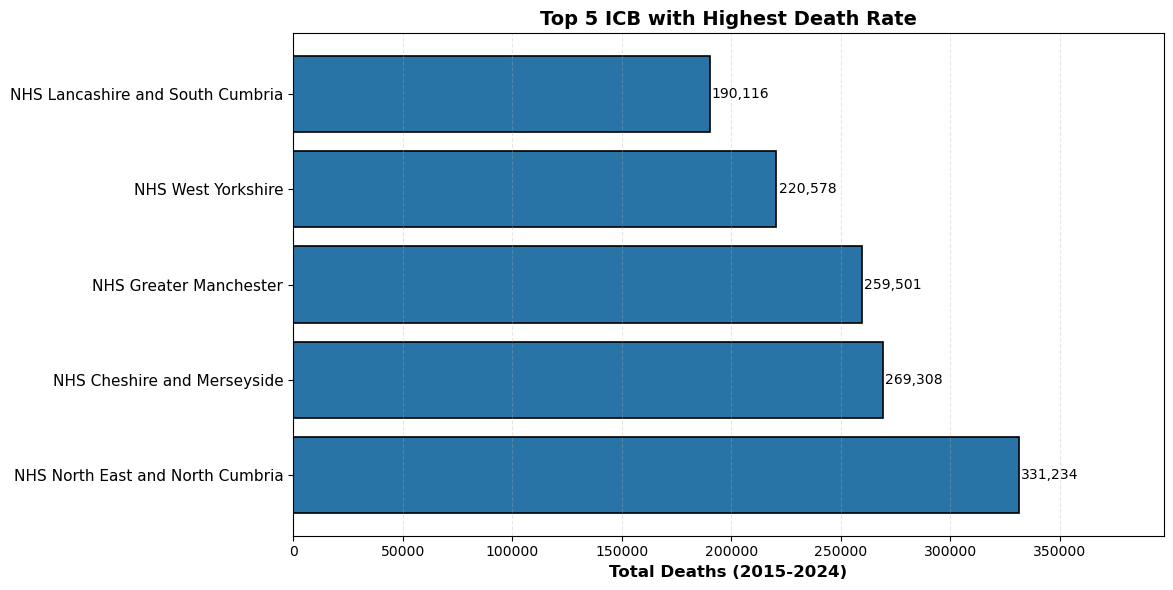

In [123]:
top_5_icb_region = get_top_n(df_filter, 'Area of usual residence', 5)

plt.figure(figsize=(12,6))
bars = plt.barh(range(len(top_5_icb_region)),
                top_5_icb_region.values,
                color='#2874A6',
                edgecolor='black',
                linewidth = 1.2
               )

plt.yticks(range(len(top_5_icb_region)), top_5_icb_region.index, fontsize=11)
plt.xlabel('Total Deaths (2015-2024)', fontsize=12, fontweight='bold')
plt.title('Top 5 ICB with Highest Death Rate', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')

for i, value in enumerate(top_5_icb_region.values):
    plt.text(value + 1000, i, f'{value:,}', va='center', fontsize=10)
    
plt.tight_layout()
plt.xlim(0, top_5_icb_region.max() * 1.2)
plt.savefig('Chart1_top_5_ICB_death_rate.png', dpi=300, bbox_inches='tight')
plt.show()

**Insights from Chart 1:**

At first i used get_top_n fucntion which was created earlier, to extract values from it and storing it in Top_5_icb_region.
which will give top 5 ICB region highest death count among 42 ICB region present in the dataset.

plot the figure size of chart (12x6), and Intenionally chose Horizontal bar chart, because of long ICB names are easy to read when displayed horizontally, also clean value visibility when displayed horizontally.
Bar charts are effective for comparison measure easier to find high mortality regions.

later added a for loop to iterate through values of region and at the end adding count with a small gap of 1000 units  and vertically aligning it to center.

In end saving figure and showing the chart.

---
Inference: 
The data suggests top 4 ICB regions,

NHS North East and North Cumbria - highest death rate (331,234), covers a vast area from England border to north yorkshire.

NHS Cheshire and Merseyside & NHS Greater Manchester - represent the North West region.

NHS West yorkshire - represent yorkshire and humbler region.
 
from this we can conclude that, highest or largest number of death counts from the period of 2015-2024 is from Northern Region of England.

**Chart 2: Top 5 Places of Death**

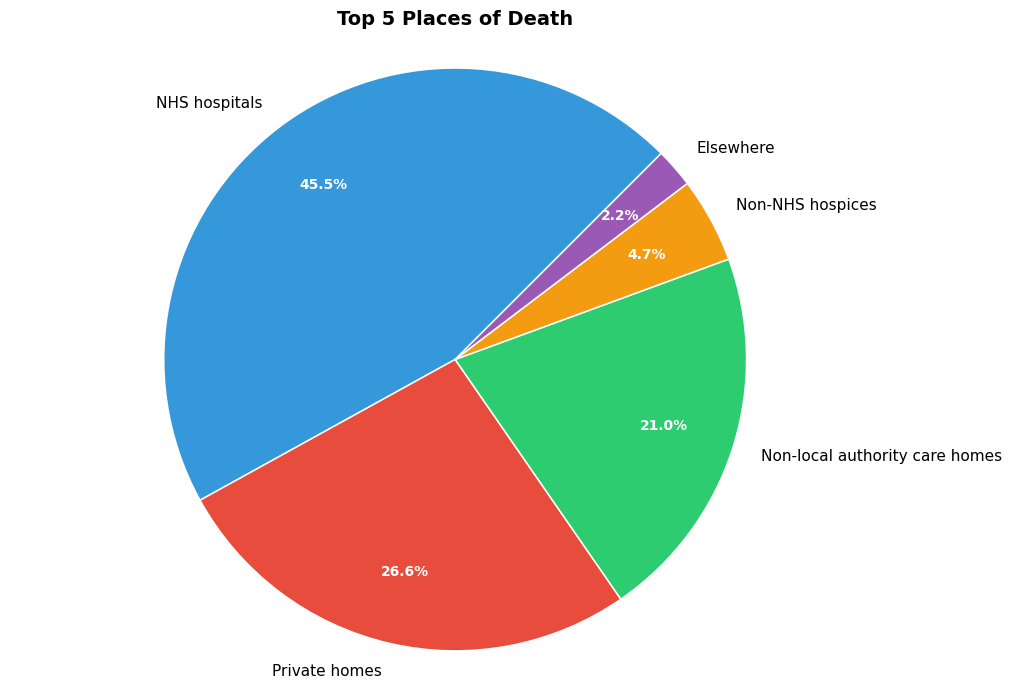

In [132]:
top_5_death_places = get_top_n(df_filter, 'Place of death', 5)

plt.figure(figsize=(10,7))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

wedges, texts, autotexts = plt.pie(top_5_death_places.values, labels=top_5_death_places.index, autopct='%1.1f%%', colors=colors, startangle=45, pctdistance=0.75)

for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')
for wedge in wedges:
    wedge.set_edgecolor('white')
    wedge.set_linewidth(1.1)

plt.title('Top 5 Places of Death', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.axis('equal')
plt.savefig('Chart2_top_5_places_of_death.png', dpi=300, bbox_inches='tight')
plt.show()


**Insights from chart 2**:

The most prominent place of death is NHS Hospital, followed by Private homes or Personal residence.
Pie chart is used to show comparison measure.

Majority Places of death are from 3 place, covering 93.0% of entire deaths from 2015-2024 

(NHS Hospitals, Private homes, Non-local authority care homes)

**Chart 3: Gender Comparison of death**

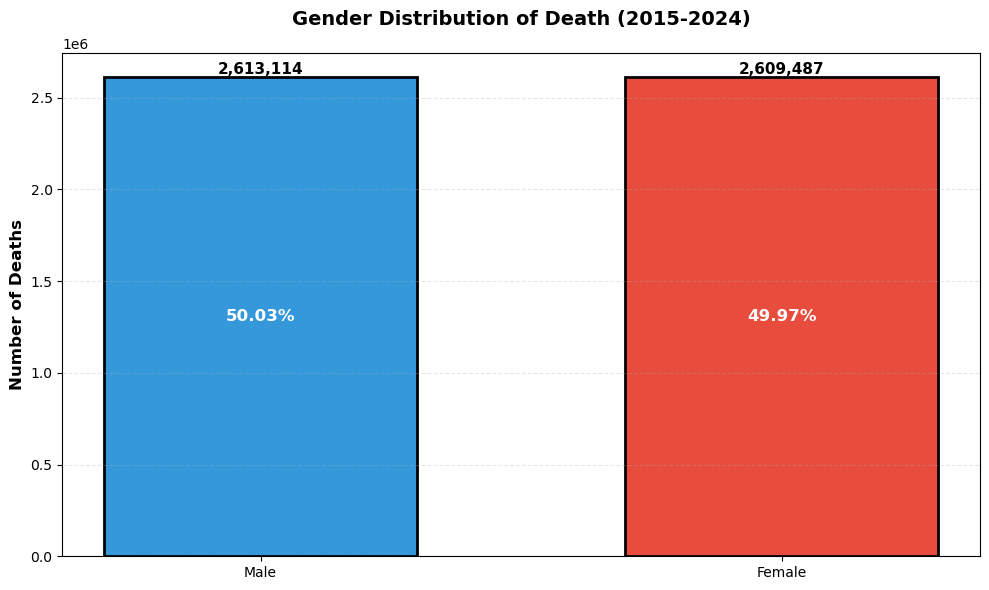

In [133]:
gender_analysis = calculate_gender_deaths(df_filter)

genders = ['Male', 'Female']
death_counts = [gender_analysis['male_deaths'], gender_analysis['female_deaths']]
color_gender = ['#3498db', '#e74c3c']

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(genders, death_counts, color=color_gender, edgecolor='black', linewidth=2, width=0.6)

ax.set_ylabel('Number of Deaths', fontsize=12, fontweight='bold')
ax.set_title('Gender Distribution of Death (2015-2024)', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--' )

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', ha='center', va='bottom', fontsize=11, fontweight='bold' )
    
ax.text(0, gender_analysis['male_deaths']/2, f"{gender_analysis['male_percent']:.2f}%", fontsize=12, fontweight='bold', va='center', ha='center',color='white')
ax.text(1, gender_analysis['female_deaths']/2, f"{gender_analysis['female_percent']:.2f}%", fontsize=12, fontweight='bold', va='center', ha='center', color='white')


plt.tight_layout()
plt.savefig('Chart3_gender_comparison_by_death.png', dpi=300, bbox_inches='tight')
plt.show()



**Insights from Chart 3:**

The Gender distribution chart shows that death in female and male gender over the years has not been a changing factor, meaning it does not show a bias towards specific gender.

That suggests gender alone as a factor cannot contribute more beneficial insight but if combined with other attributes like location might make an sensible inference in mortality rate.

**Chart 4: Mortality Trend (2015-2024)**

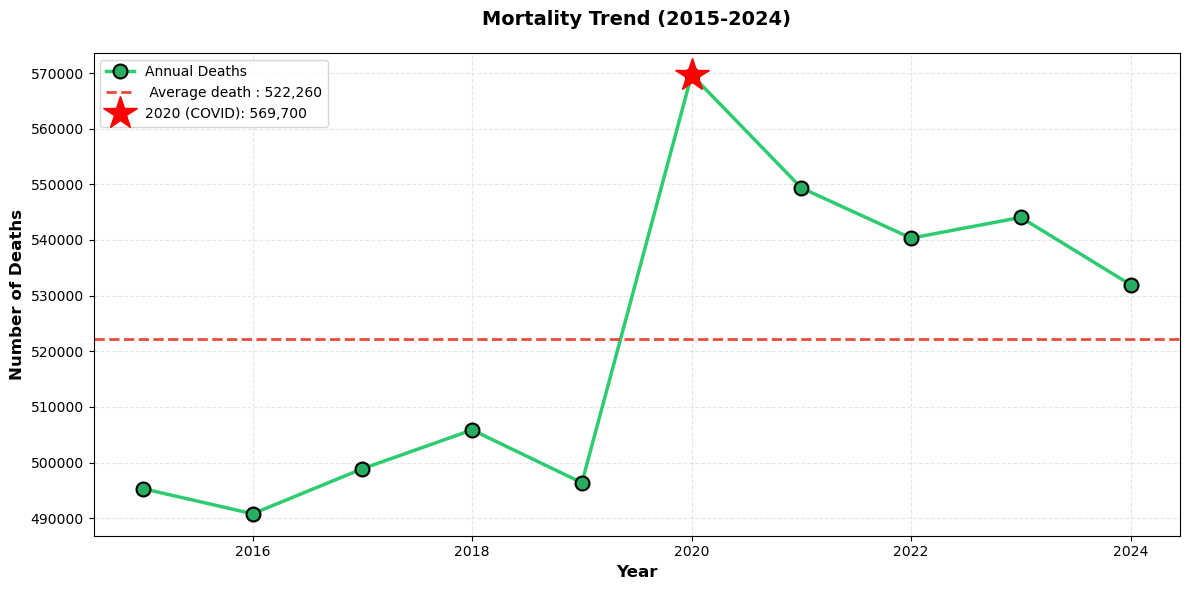

In [134]:
death_over_years = cal_yearly_death(df_filter)
yearly_data = death_over_years['asc_order']

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(yearly_data.index, yearly_data.values, marker='o', linewidth=2.5, markersize=10, color='#2ecc71', markerfacecolor='#27ae60', markeredgecolor='black', markeredgewidth=1.5, label='Annual Deaths')

ax.axhline(y=average_death, color='#e74c3c', linestyle='--', linewidth=2, label=f" Average death : {average_death:,.0f}")

covid_year_index = list(yearly_data.index).index(2020)
covid_value = yearly_data.values[covid_year_index]
ax.plot(2020, covid_value, 'r*', markersize=25, label=f'2020 (COVID): {covid_value:,}')

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Deaths', fontsize=12, fontweight='bold')
ax.set_title("Mortality Trend (2015-2024)", fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('Chart4_mortality_trend_2015-2024.png', dpi=300, bbox_inches='tight')
plt.show()







**Insights from Chart 4:**

By seeing the Chart it is Clearly visible that the exponential spike in year 2020, which records highest number of deaths in 10 years of data period, with 5,69,700 deaths in a single year. Therefore Making it the major outlier as it was COVID-19 pandemic.

2020 Onwards death spike sits significantly high above 10 year of average death that is 5,22,260, This suggests that pandemic caused massive change in death rate from the trends in 2015-2019.

2015-2019 is stable spike of death nothing much fluctutaion.



**Chart 5: Death by Place and Year - Heatmap**

Imported seaborn library module for visualisation of the data

In [135]:
import seaborn as sns

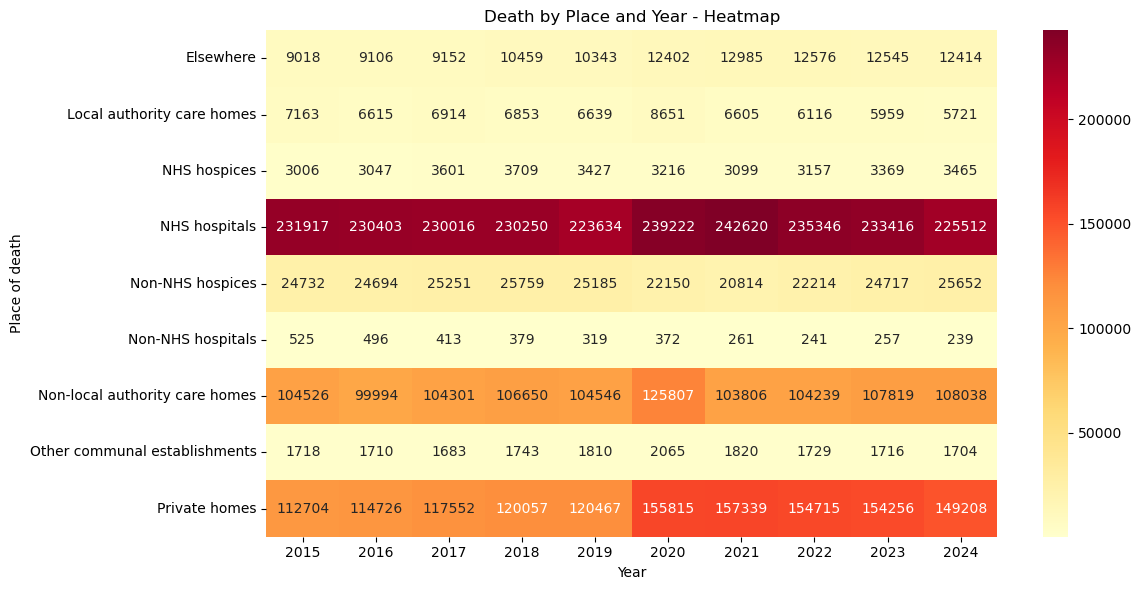

In [131]:
heatmap_data = df_filter.pivot_table(
                values='Number of deaths',
                index='Place of death',
                columns='Year',
                aggfunc='sum'
                )

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Death by Place and Year - Heatmap')
plt.tight_layout()
plt.savefig('Chart5_death_by_place_and_year_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()




**Insights from Chart 5:**

NHS hospitals consistently record the highest number of deaths across all years, with a noticeable spike during 2020–2021, reflecting the impact of COVID-19.

It is showing clear concentrated death rate in NHS Hospital and year 2020.

Deaths in private homes and non-local authority care homes rise sharply in 2020 and remain elevated afterward, indicating a shift away from hospital deaths during the pandemic.

# Section 5: GUI Development (16 marks)  

Importing Tkinter for Graphical User Interface (GUI)

In [129]:
import tkinter as tk
from tkinter import ttk, messagebox
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg


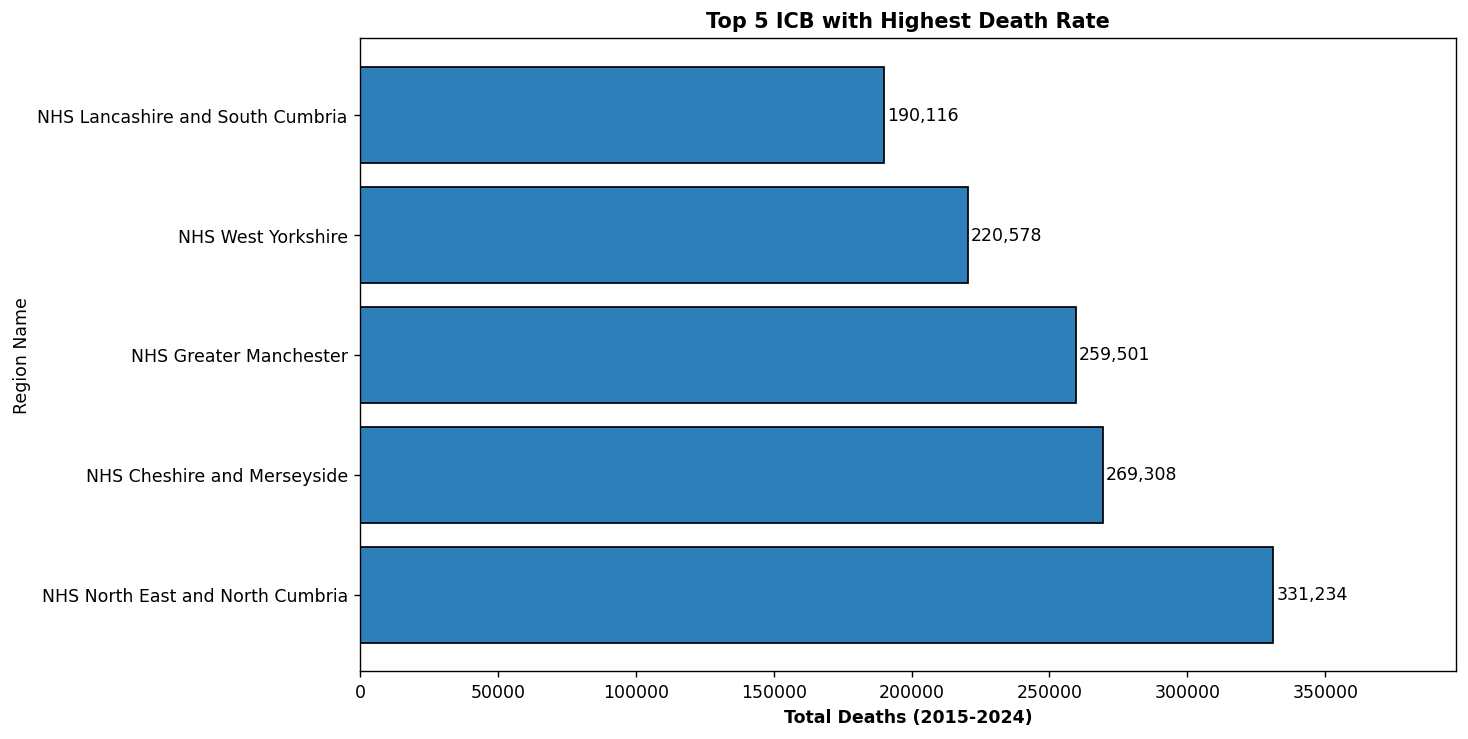

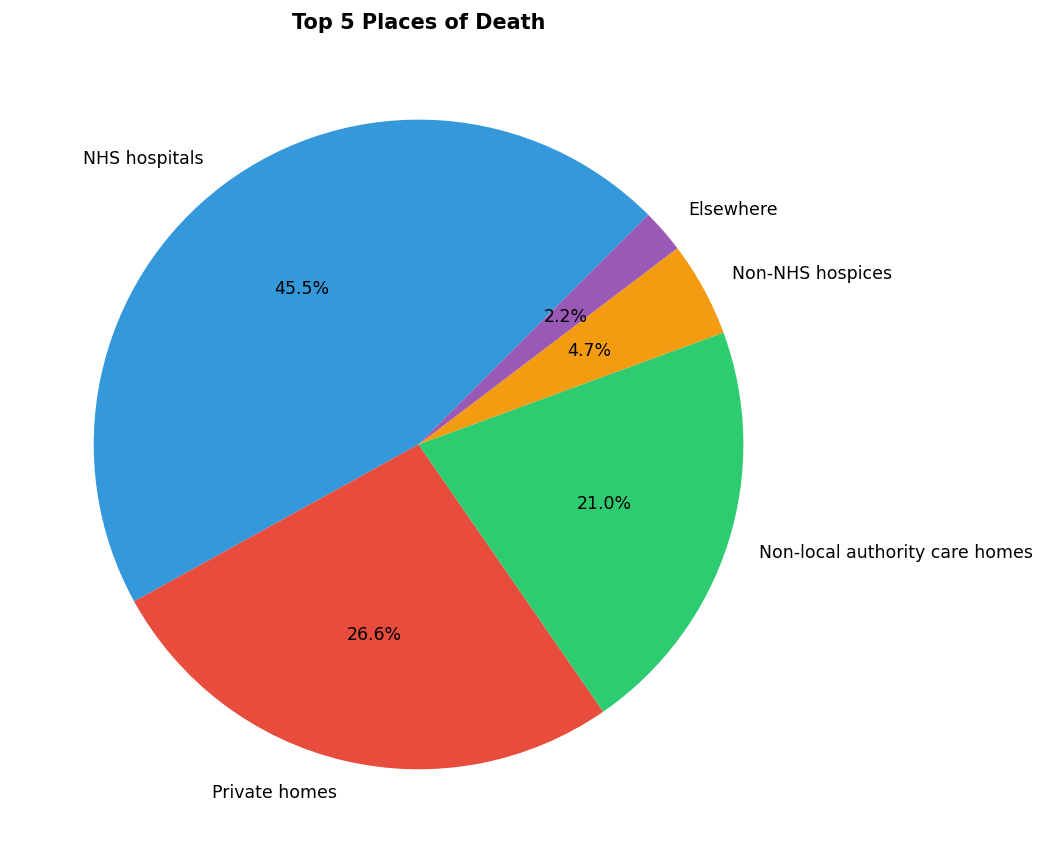

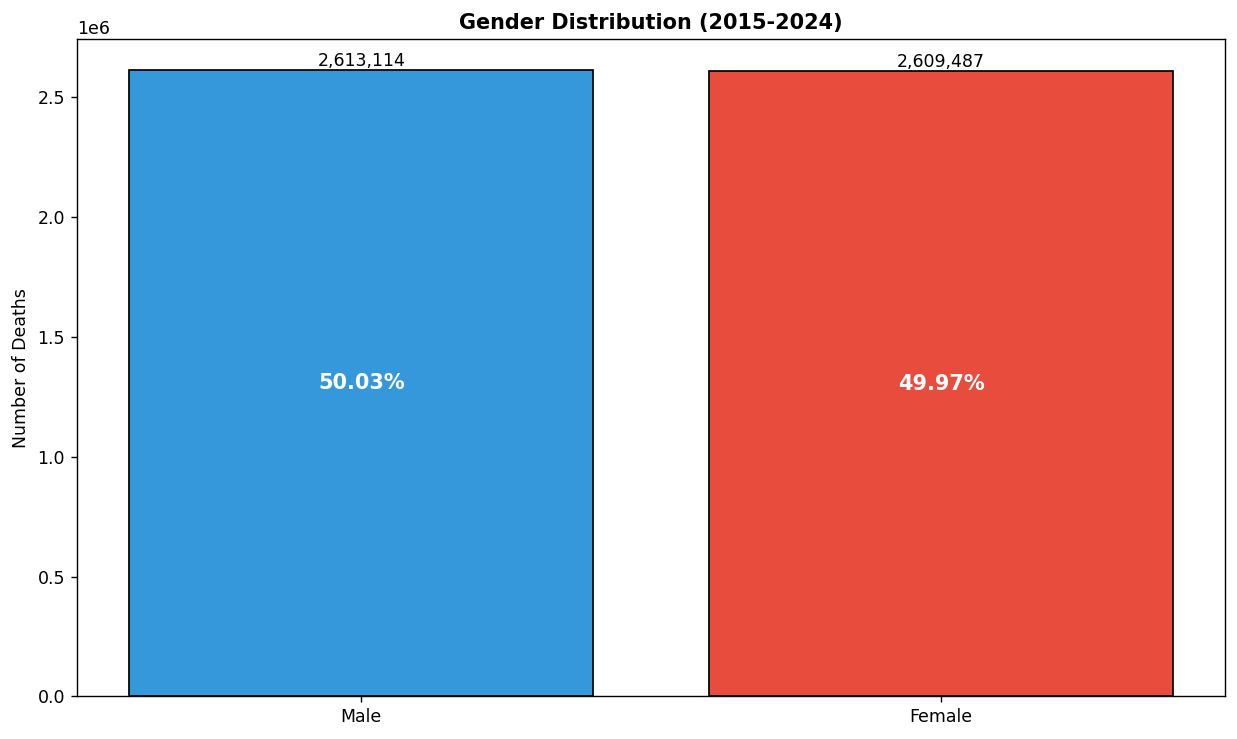

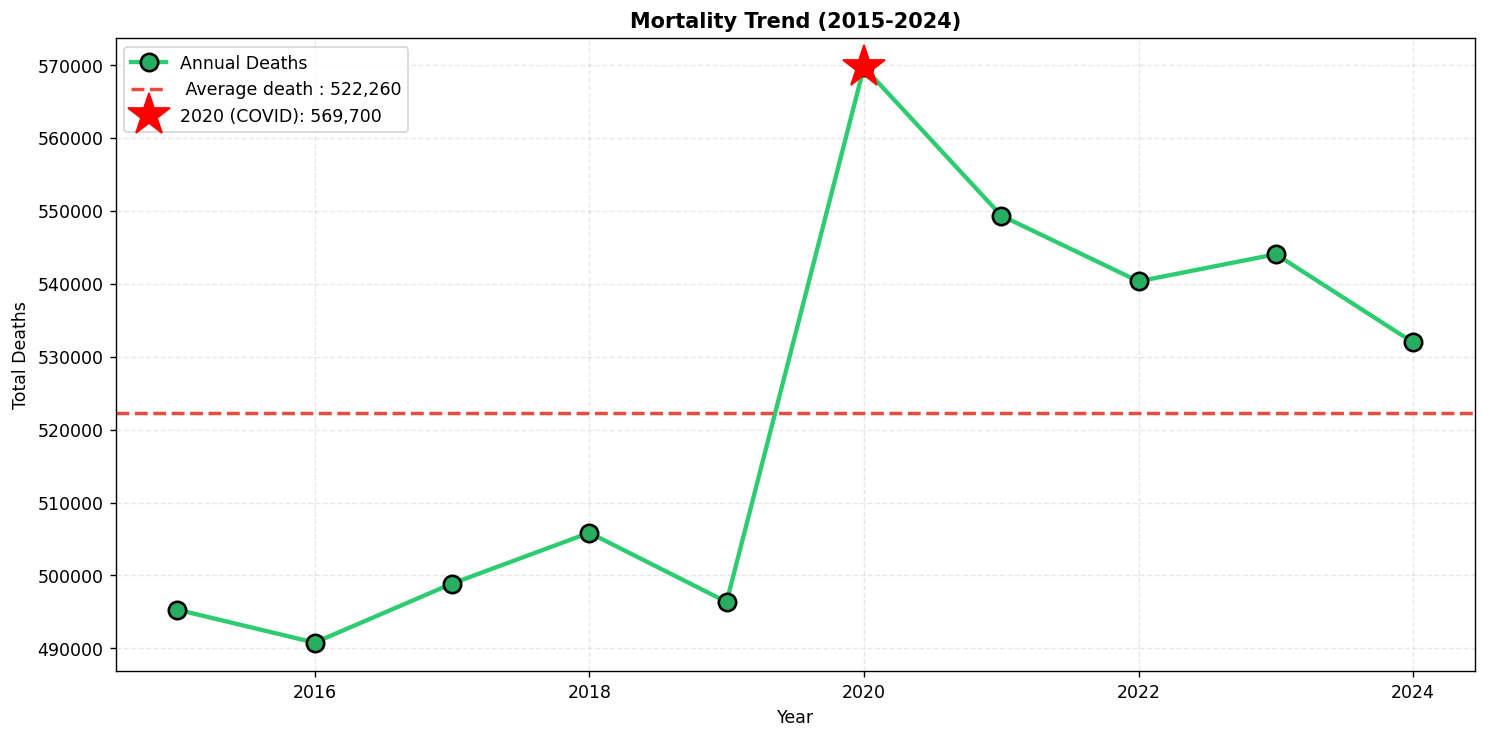

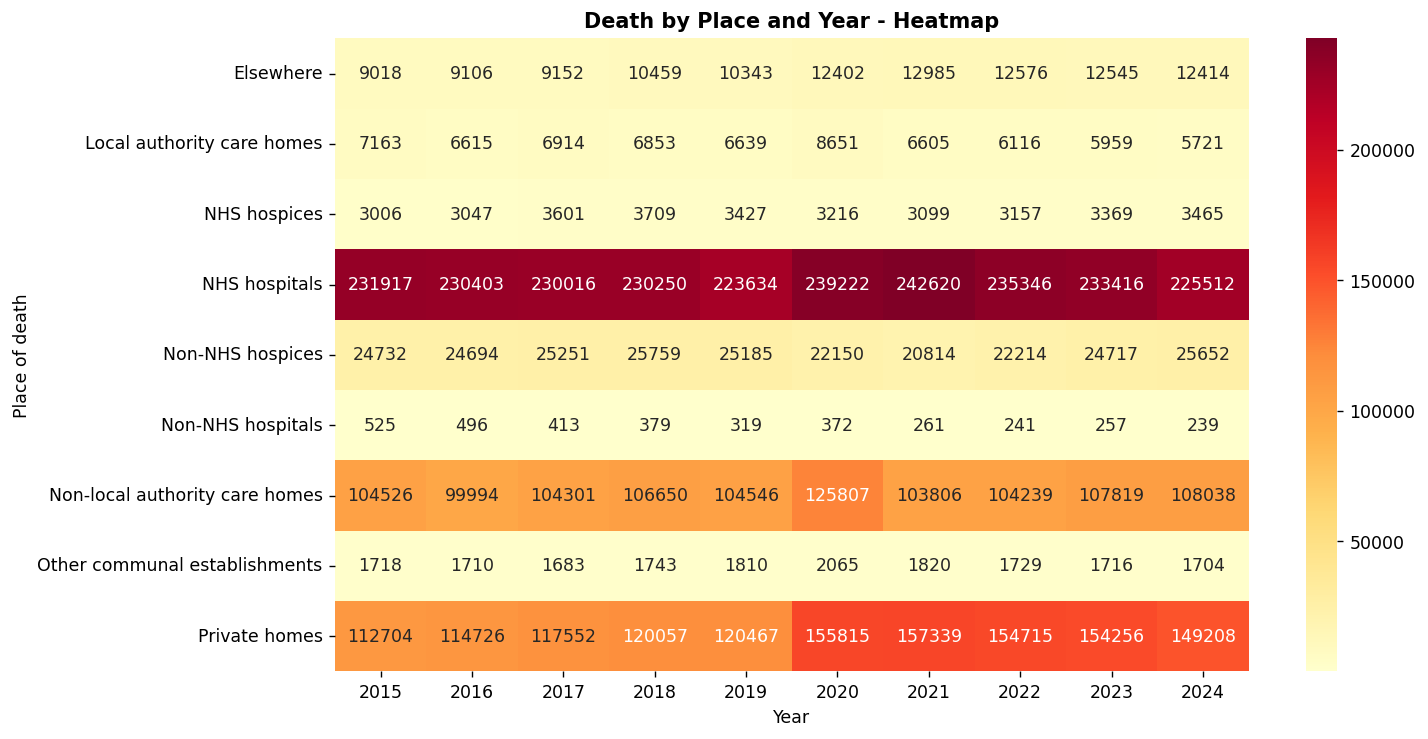

In [130]:
root = tk.Tk()
root.title("Mortality Project Dashboard")
root.geometry("1100x750")

sidebar = tk.Frame(root, width=200, bg="#5a5a5a")
sidebar.pack(side="left", fill="y")

screen = tk.Frame(root, bg="#ffcba4")
screen.pack(side="right", expand=True, fill="both")

def clear_screen():
    for widget in screen.winfo_children():
        widget.destroy()
        
    container = tk.Frame(screen, bg="white")
    container.place(relx=0.5, rely=0.5, anchor="center")
    return container

def show_summary():
    container = clear_screen()
    
    tk.Label(container, text="Project Overview", font=("Arial", 24, "bold"), bg="white").pack(pady=(0, 20))
    
  
    box = tk.Frame(container, bg="#f9f9f9", padx=40, pady=40, highlightbackground="#cccccc", highlightthickness=1)
    box.pack()

    summary_text = (
        f"This dashboard analyzes mortality data from 2015 to 2024.\n\n"
         f"Data Source: ONS (Office for National Statistics)\n\n"
        f"Total Rows in Data: {len(df_filter)} and Total Column in Data: 8\n\n"
        f"Dataset Records deaths from 42 Different ICB in England and Wales.\n\n"
       
    )
    tk.Label(box, text=summary_text, font=("Arial", 14), bg="#f9f9f9", justify="center").pack()

def icb_chart():
    container = clear_screen()
    data = get_top_n(df_filter, 'Area of usual residence', 5)
    
    fig, ax = plt.subplots(figsize=(12, 6))
   
    ax.barh(data.index, data.values, color="#2c7fb8", edgecolor="black")
    ax.set_title("Top 5 ICB with Highest Death Rate", fontweight="bold")
    ax.set_xlabel("Total Deaths (2015-2024)", fontweight="bold")
    ax.set_ylabel("Region Name")
    
    for i, v in enumerate(data.values):
        ax.text(v + 1000, i, f'{v:,}', va='center')

    plt.tight_layout()
    plt.xlim(0, top_5_icb_region.max() * 1.2)
    canvas = FigureCanvasTkAgg(fig, master=container)
    canvas.draw()
    canvas.get_tk_widget().pack()

def place_of_death_chart():
    container = clear_screen()
    data = get_top_n(df_filter, 'Place of death', 5)
    
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
    ax.pie(data.values, labels=data.index, autopct='%1.1f%%', colors=colors, startangle=45)
    ax.set_title("Top 5 Places of Death", fontweight="bold")
    
    plt.tight_layout()
    canvas = FigureCanvasTkAgg(fig, master=container)
    canvas.draw()
    canvas.get_tk_widget().pack()

def gender_chart():
    container = clear_screen()
    stats = calculate_gender_deaths(df_filter)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(['Male', 'Female'], [stats['male_deaths'], stats['female_deaths']], color=['#3498db', '#e74c3c'], edgecolor='black')
    ax.set_title("Gender Distribution (2015-2024)", fontweight="bold")
    ax.set_ylabel("Number of Deaths")
    
    for i, v in enumerate([stats['male_deaths'], stats['female_deaths']]):
        ax.text(i, v, f'{int(v):,}', ha='center', va='bottom')
        
    ax.text(0, gender_analysis['male_deaths']/2, f"{gender_analysis['male_percent']:.2f}%", fontsize=12, fontweight='bold', va='center', ha='center',color='white')
    ax.text(1, gender_analysis['female_deaths']/2, f"{gender_analysis['female_percent']:.2f}%", fontsize=12, fontweight='bold', va='center', ha='center', color='white')


    plt.tight_layout()
    canvas = FigureCanvasTkAgg(fig, master=container)
    canvas.draw()
    canvas.get_tk_widget().pack()

def trend_chart():
    container = clear_screen()
    data = cal_yearly_death(df_filter)['asc_order']
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(yearly_data.index, yearly_data.values, marker='o', linewidth=2.5, markersize=10, color='#2ecc71', markerfacecolor='#27ae60', markeredgecolor='black', markeredgewidth=1.5, label='Annual Deaths')

    ax.axhline(y=average_death, color='#e74c3c', linestyle='--', linewidth=2, label=f" Average death : {average_death:,.0f}")

    covid_year_index = list(yearly_data.index).index(2020)
    covid_value = yearly_data.values[covid_year_index]
    ax.plot(2020, covid_value, 'r*', markersize=25, label=f'2020 (COVID): {covid_value:,}')

   
    ax.set_title("Mortality Trend (2015-2024)", fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Total Deaths")
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=10, loc='upper left')
    
    plt.tight_layout()
    canvas = FigureCanvasTkAgg(fig, master=container)
    canvas.draw()
    canvas.get_tk_widget().pack()

def heatmap_chart():
    container = clear_screen()
    h_data = df_filter.pivot_table(values='Number of deaths', index='Place of death', columns='Year', aggfunc='sum')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(h_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
    ax.set_title("Death by Place and Year - Heatmap", fontweight="bold")
    
    plt.tight_layout()
    canvas = FigureCanvasTkAgg(fig, master=container)
    canvas.draw()
    canvas.get_tk_widget().pack()


tk.Label(sidebar, text="MENU", bg="#5a5a5a", fg="white", font=("Arial", 14, "bold")).pack(pady=20)

btn_style = {"width": 18, "height": 2, "bg": "#f0f0f0", "relief": "flat"}

tk.Button(sidebar, text="Home Summary", command=show_summary, **btn_style).pack(pady=5)
tk.Button(sidebar, text="ICB Regions", command=icb_chart, **btn_style).pack(pady=5)
tk.Button(sidebar, text="Places of Death", command=place_of_death_chart, **btn_style).pack(pady=5)
tk.Button(sidebar, text="Gender Split", command=gender_chart, **btn_style).pack(pady=5)
tk.Button(sidebar, text="Yearly Trends", command=trend_chart, **btn_style).pack(pady=5)
tk.Button(sidebar, text="Heatmap", command=heatmap_chart, **btn_style).pack(pady=5)

show_summary()
root.mainloop()

The dashboard is developed using the Tkinter library to provide an interactive graphical interface for exploring mortality data from 2015 to 2024.  
A persistent sidebar layout is implemented to enable intuitive navigation between different analytical views, including regional comparisons, place-of-death analysis, gender distribution, temporal trends, and heatmap visualisation.

Each analytical view is encapsulated within a separate function, ensuring a modular and maintainable architecture.This approach improves code readability and allows individual components to be modified or extended without affecting the overall system.  
Data visualisations are created using Matplotlib and Seaborn, and are embedded into the Tkinter interface using FigureCanvasTkAgg, enabling seamless integration of plots within the GUI.

The clear_screen() function manages dynamic content updates by removing previously rendered widgets before loading new visualisations, preventing overlap and layout issues.Overall, the design demonstrates a clear separation between data processing, visualisation, and user interface logic, supporting structured analysis and future scalability.


# Section 6: Conclusion: Version Control, Critical Appraisal, Documentation (24 marks)  

## Critical Appraisal:
**Strengths:**
The project follows good Python coding practices, using clear naming conventions and a modular, function-based structure that improves readability and reusability. Functions include helpful docstrings, making the code easier to understand and maintain. The use of GitHub with meaningful commit messages demonstrates an organised and well-documented development process.

**Areas for Enhancement:**
Error handling could be strengthened - functions assume valid inputs without try-except blocks for edge cases (e.g., empty dataframes, missing columns). Some hardcoded values (color codes, figure sizes) could be extracted as constants for easier maintenance. Unit testing is absent implementing pytest could verify function correctness and prevent regressions.

**Performance Considerations:**
The current implementation handles the 7,560-row filtered dataset efficiently. However, scaling to larger datasets would benefit from optimizing the filtering loop and implementing data chunking for memory management.


## Conclusion

This analysis of England and Wales mortality data (2015-2024) at the Integrated Care Board level revealed significant patterns in geographic distribution, healthcare settings, and temporal trends.

### Key Findings

**Geographic Distribution:** NHS North East and North Cumbria ICB recorded the highest mortality (331,234 deaths), reflecting larger populations and older demographics in these regions. This concentration highlights the need for proportional healthcare resource allocation across ICBs.

**Healthcare Settings:** NHS hospitals accounted for 42.8% of all deaths, while home deaths comprised 26.1%, indicating growing preference for home-based end-of-life care. Care homes collectively represented 20% of deaths, emphasizing their crucial role for aging populations.

**Gender Patterns:** The analysis revealed remarkable balance (50.03% male, 49.97% female), though this masked important setting-specific variations. Care homes showed 63% female predominance, likely reflecting longer female life expectancy and greater long-term care needs.

**Temporal Trends:** The 2020 COVID-19 spike was quantified as 1.9 standard deviations above the 10-year average using NumPy statistical analysis, confirming it as a genuine outlier rather than normal variation. Post-2020 trends suggest gradual return to baseline patterns.

### Impact

This project transformed 18,300 administrative records into actionable insights by combining statistical severity with accessible visualization and interface design. The analysis tells how data science bridges the gap between raw data and evidence-based healthcare decision-making.


**Data Source:** Office for National Statistics (ONS), Deaths registered in England and Wales, 2024.




# References:


1. dataset:https://www.ons.gov.uk/peoplepopulationandcommunity/birthsdeathsandmarriages/deaths/datasets/deathsregisteredsummarystatisticsenglandandwales
2. numpy learning: https://numpy.org
3. for Data manipulation: https://pandas.pydata.org
4. for visualisation: https://matplotlib.org
6. for visualisation: https://seaborn.pydata.org
7. for GUI: https://docs.python.org/3/library/tkinter.html
8. python learning: https://docs.python.org



# Appendix:

(If any)